Plot saved as 5-theoretical_observable_height_heatmap.png


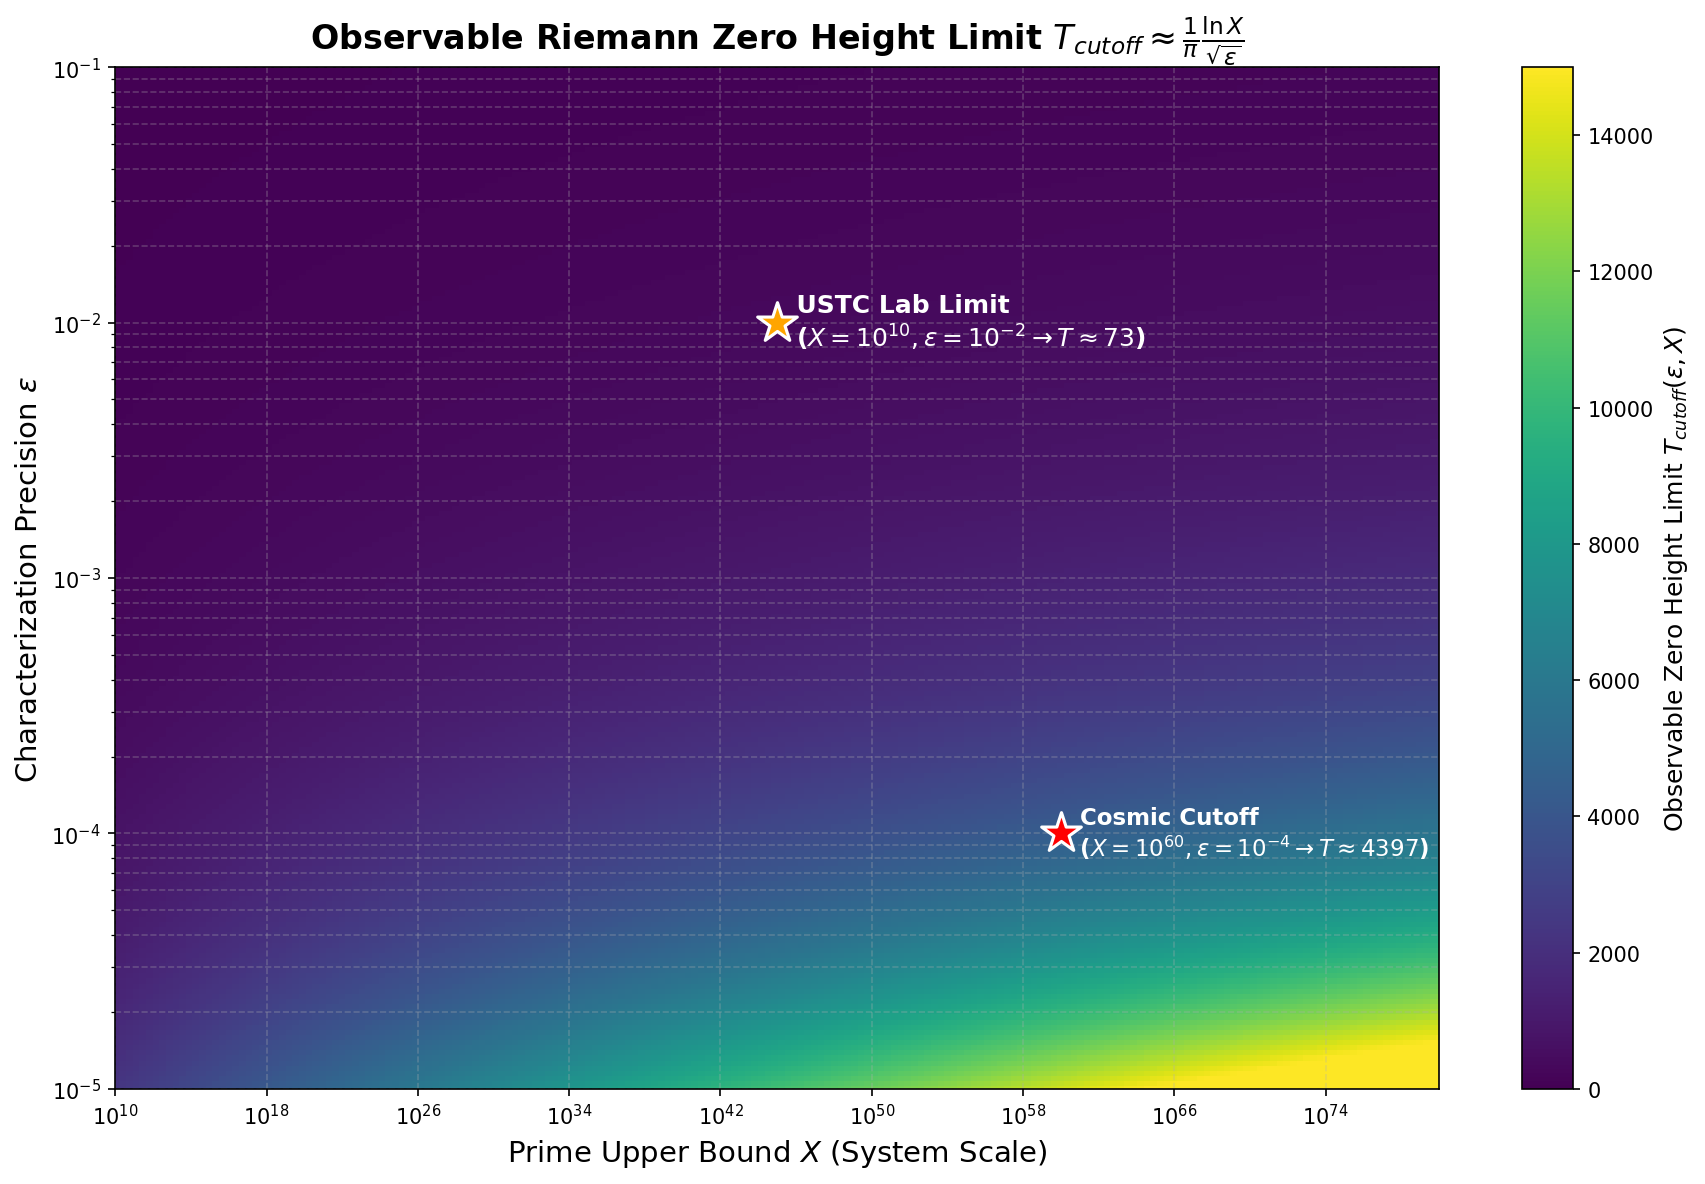

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ========== 跨系统字体配置 ==========
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'DejaVu Sans', 'Ubuntu', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150  
plt.rcParams['savefig.dpi'] = 300

# ========== 核心理论函数：基于相位涨落与奈奎斯特采样 ==========
def calculate_observable_height(epsilon, X):
    """
    纯物理理论推导公式： T_cutoff = (1/π) * (ln X / sqrt(ε))
    由素数晶格相位调制频率(ln X)与基于系统本底涨落(sqrt(ε))结合得出。
    """
    # np.log 在 numpy 中即为自然对数 ln
    T = (1.0 / np.pi) * (np.log(X) / np.sqrt(epsilon))
    
    # 限制上限，防止图表颜色被极端值拉扯，主要展示有效区间
    T = np.clip(T, 0, 1.5e4)
    return T

# ========== 生成正确的网格数据 ==========
# 素数上限X：10^10 ~ 10^80（从 10^10 起步以覆盖 USTC 实验尺度）
X_range = np.logspace(10, 80, 200)  
# 系统表征精度ε：10^-5 ~ 10^-1
epsilon_range = np.logspace(-5, -1, 200)

# 生成网格
X_mesh, epsilon_mesh = np.meshgrid(X_range, epsilon_range)
T_mesh = calculate_observable_height(epsilon_mesh, X_mesh)

# ========== 绘制热力图 ==========
fig, ax = plt.subplots(figsize=(12, 8))

# 绘制热力图
im = ax.pcolormesh(
    X_mesh, epsilon_mesh, T_mesh,
    norm=colors.Normalize(vmin=0, vmax=1.5e4),
    cmap='viridis',
    shading='auto'
)

# ========== 坐标轴范围与刻度 ==========
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(X_range.min(), X_range.max())
ax.set_ylim(epsilon_range.min(), epsilon_range.max())

# 🔥 核心物理锚点标注 🔥

# 1. 宇宙极限点 (Cosmic Cutoff) -> ln(10^60) / (π*sqrt(10^-4)) ≈ 4397
ax.scatter(1e60, 1e-4, color='red', marker='*', s=400, edgecolor='white', linewidth=1.5, zorder=5)
ax.text(1e60 * 1.5, 1e-4, r'  Cosmic Cutoff' + '\n' + r'  ($X=10^{60}, \epsilon=10^{-4} \rightarrow T \approx 4397$)', 
        color='white', fontsize=11, fontweight='bold', va='center')

# 2. 实验室极缺点 (USTC Lab Limit) -> ln(10^10) / (π*sqrt(10^-2)) ≈ 73.3
# 为防止文字遮挡，将星星画在图表中部的开阔地带 (X=1e45附近)
lab_x_new = 1e45  
lab_y_current = 1e-2 
text_offset = 1.25 # 文字偏移因子

# 绘制修正后的星形标识
ax.scatter(lab_x_new, lab_y_current, color='orange', marker='*', s=400, edgecolor='white', linewidth=1.5, zorder=5)

# 文本拆分为三行以保持紧凑
new_lab_text_content = (
    r'  USTC Lab Limit' + '\n' +
    r'  ($X=10^{10}, \epsilon=10^{-2} \rightarrow T \approx 73$)'           
)
ax.text(lab_x_new * text_offset, lab_y_current, new_lab_text_content,
        color='white', fontsize=12, fontweight='bold', va='center')

# ========== 文本与标签美化 ==========
ax.set_xlabel('Prime Upper Bound $X$ (System Scale)', fontsize=14)
ax.set_ylabel(r'Characterization Precision $\epsilon$', fontsize=14)
ax.set_title(r'Observable Riemann Zero Height Limit $T_{cutoff} \approx \frac{1}{\pi} \frac{\ln X}{\sqrt{\epsilon}}$', fontsize=16, fontweight='bold')

# 颜色条 (注意使用 r 前缀避免转义报错)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Observable Zero Height Limit $T_{cutoff}(\epsilon, X)$', fontsize=12)

# 网格线
ax.grid(True, alpha=0.3, which='both', linestyle='--')

# 保存与显示
plt.tight_layout()
plt.savefig('5-theoretical_observable_height_heatmap.png', bbox_inches='tight')
print("Plot saved as 5-theoretical_observable_height_heatmap.png")
plt.show()